# Emotion Detection with Essay Chunking: AI Essays vs Humanized Essays

This notebook uses the **RoBERTa-based GoEmotions** model from HuggingFace to detect emotions in essays, with **SpaCy-based essay chunking** to analyze emotions per section.

**Methodology:**
1. Load the dataset (`datasets.csv`) - filter to length 2 and 3 essays only
2. Use SpaCy to segment essays into **Introduction**, **Body**, and **Conclusion** sections
3. Use the GoEmotions model to predict emotions for each section
4. Compare emotion distributions across sections between AI essays and Humanized essays
5. Visualize the emotional flow from Intro → Body → Conclusion

**Note:** Length 1 essays are excluded as they are too short to meaningfully chunk.

In [ ]:
# Install dependencies
# !pip install transformers torch pandas matplotlib seaborn tqdm spacy
# !python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/12.8 MB ? eta -:--:--  Downloading https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 703.4 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 703.4 kB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm
import spacy
import warnings
warnings.filterwarnings('ignore')

# Load SpaCy model for sentence segmentation
print("Loading SpaCy model...")
nlp = spacy.load("en_core_web_sm")
print("SpaCy loaded!")

# Load GoEmotions model from HuggingFace
print("Loading GoEmotions model (SamLowe/roberta-base-go_emotions)...")
emotion_classifier = pipeline(
    "text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=None,
    truncation=True
)
print("Model loaded successfully!")

/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/opt/miniconda3/envs/testenv/lib/python3.9/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.regi

Loading SpaCy model...
SpaCy loaded!
Loading GoEmotions model (SamLowe/roberta-base-go_emotions)...
SpaCy loaded!
Loading GoEmotions model (SamLowe/roberta-base-go_emotions)...
Model loaded successfully!
Model loaded successfully!


In [3]:
# Load dataset and filter to length 2 and 3 only
dataset_path = '../datasets.csv'

df_full = pd.read_csv(dataset_path)
print(f"Full dataset: {df_full.shape}")

# Filter to length 2 and 3 (exclude length 1 - too short to chunk)
df = df_full[df_full['length'].isin([2, 3])].copy().reset_index(drop=True)
print(f"Filtered dataset (length 2 & 3 only): {df.shape}")
print(f"\nLength distribution:")
print(df['length'].value_counts())
display(df.head(2))

Full dataset: (180, 6)
Filtered dataset (length 2 & 3 only): (120, 6)

Length distribution:
length
2    60
3    60
Name: count, dtype: int64


,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...
1,1,2,gemini2.5pro,Grammarly,The pervasive integration of social media into...,Social media has become a major part of young ...


In [4]:
def chunk_essay_spacy(text, nlp):
    """
    Chunk an essay into Introduction, Body, and Conclusion using SpaCy.
    
    Strategy:
    - Use SpaCy to split text into sentences
    - Introduction: First ~15% of sentences (min 1)
    - Conclusion: Last ~15% of sentences (min 1)  
    - Body: Everything in between
    
    Returns dict with 'intro', 'body', 'conclusion' keys
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {'intro': '', 'body': '', 'conclusion': ''}
    
    # Process with SpaCy for sentence segmentation
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
    
    if len(sentences) == 0:
        return {'intro': '', 'body': '', 'conclusion': ''}
    
    n_sents = len(sentences)
    
    if n_sents == 1:
        return {'intro': sentences[0], 'body': '', 'conclusion': ''}
    elif n_sents == 2:
        return {'intro': sentences[0], 'body': '', 'conclusion': sentences[1]}
    elif n_sents <= 5:
        # For short essays: 1 intro, middle as body, 1 conclusion
        return {
            'intro': sentences[0],
            'body': ' '.join(sentences[1:-1]),
            'conclusion': sentences[-1]
        }
    else:
        # For longer essays: ~15% intro, ~15% conclusion, rest is body
        intro_end = max(1, int(n_sents * 0.15))
        conclusion_start = min(n_sents - 1, n_sents - max(1, int(n_sents * 0.15)))
        
        return {
            'intro': ' '.join(sentences[:intro_end]),
            'body': ' '.join(sentences[intro_end:conclusion_start]),
            'conclusion': ' '.join(sentences[conclusion_start:])
        }


def get_emotions(text):
    """Get emotion predictions for a text. Returns dict of {emotion: score}"""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}
    
    # Truncate to ~2000 chars for RoBERTa token limit
    text_truncated = text[:2000]
    
    try:
        results = emotion_classifier(text_truncated)
        emotions = {r['label']: r['score'] for r in results[0]}
        return emotions
    except Exception as e:
        print(f"Error: {e}")
        return {}


def get_top_emotion(emotions_dict):
    """Get the emotion with highest score"""
    if not emotions_dict:
        return "unknown"
    return max(emotions_dict, key=emotions_dict.get)


print("Essay chunking and emotion extraction functions defined.")

Essay chunking and emotion extraction functions defined.


In [5]:
# Step 1: Chunk all essays using SpaCy
tqdm.pandas()

print("Chunking AI Essays...")
df['AI_chunks'] = df['AI_essay'].progress_apply(lambda x: chunk_essay_spacy(x, nlp))

print("\nChunking Humanized Essays...")
df['Human_chunks'] = df['humanized_essay'].progress_apply(lambda x: chunk_essay_spacy(x, nlp))

# Preview chunking results
print("\nSample chunking result (AI essay):")
sample_chunks = df['AI_chunks'].iloc[0]
for section, text in sample_chunks.items():
    print(f"\n{section.upper()} ({len(text)} chars):")
    print(text[:200] + "..." if len(text) > 200 else text)

Chunking AI Essays...


100%|██████████| 120/120 [00:17<00:00,  6.76it/s]



Chunking Humanized Essays...


100%|██████████| 120/120 [00:15<00:00,  7.72it/s]


Sample chunking result (AI essay):

INTRO (539 chars):
The pervasive integration of social media into the lives of young people represents one of the most significant sociological shifts of the modern era. What began as a novel way to connect with friends...

BODY (3031 chars):
Social media is not a neutral tool; it is an environment engineered for addiction, and its core mechanics are actively undermining the healthy development of an entire generation, making its net impac...

CONCLUSION (532 chars):
These platforms are engineered by behavioral psychologists to be as addictive as possible, exploiting the vulnerabilities of the developing adolescent brain. We are not dealing with a passive tool but...


In [6]:
# Step 2: Get emotions for each section (Intro, Body, Conclusion)
sections = ['intro', 'body', 'conclusion']

print("Analyzing emotions per section for AI Essays...")
for section in sections:
    print(f"  Processing {section}...")
    df[f'AI_{section}_emotions'] = df['AI_chunks'].progress_apply(
        lambda x: get_emotions(x.get(section, ''))
    )
    df[f'AI_{section}_top'] = df[f'AI_{section}_emotions'].apply(get_top_emotion)

print("\nAnalyzing emotions per section for Humanized Essays...")
for section in sections:
    print(f"  Processing {section}...")
    df[f'Human_{section}_emotions'] = df['Human_chunks'].progress_apply(
        lambda x: get_emotions(x.get(section, ''))
    )
    df[f'Human_{section}_top'] = df[f'Human_{section}_emotions'].apply(get_top_emotion)

print("\nProcessing complete!")

# Preview results
display(df[['topic', 'humanizer', 'AI_intro_top', 'AI_body_top', 'AI_conclusion_top', 
            'Human_intro_top', 'Human_body_top', 'Human_conclusion_top']].head(5))

Analyzing emotions per section for AI Essays...
  Processing intro...


100%|██████████| 120/120 [00:11<00:00, 10.54it/s]


  Processing body...


100%|██████████| 120/120 [00:21<00:00,  5.61it/s]


  Processing conclusion...


...

100%|██████████| 120/120 [00:19<00:00,  6.17it/s]


  Processing conclusion...


100%|██████████| 120/120 [00:08<00:00, 13.47it/s]




Processing complete!


,topic,humanizer,AI_intro_top,AI_body_top,AI_conclusion_top,Human_intro_top,Human_body_top,Human_conclusion_top
0,1,AIHumanizer,neutral,disappointment,neutral,realization,neutral,neutral
1,1,Grammarly,neutral,disappointment,neutral,neutral,neutral,disapproval
2,1,HumanizeAI,neutral,disappointment,neutral,neutral,neutral,neutral
3,1,Quillbot,neutral,disappointment,neutral,neutral,neutral,neutral
4,1,UndetectableAI,neutral,disappointment,neutral,approval,neutral,neutral


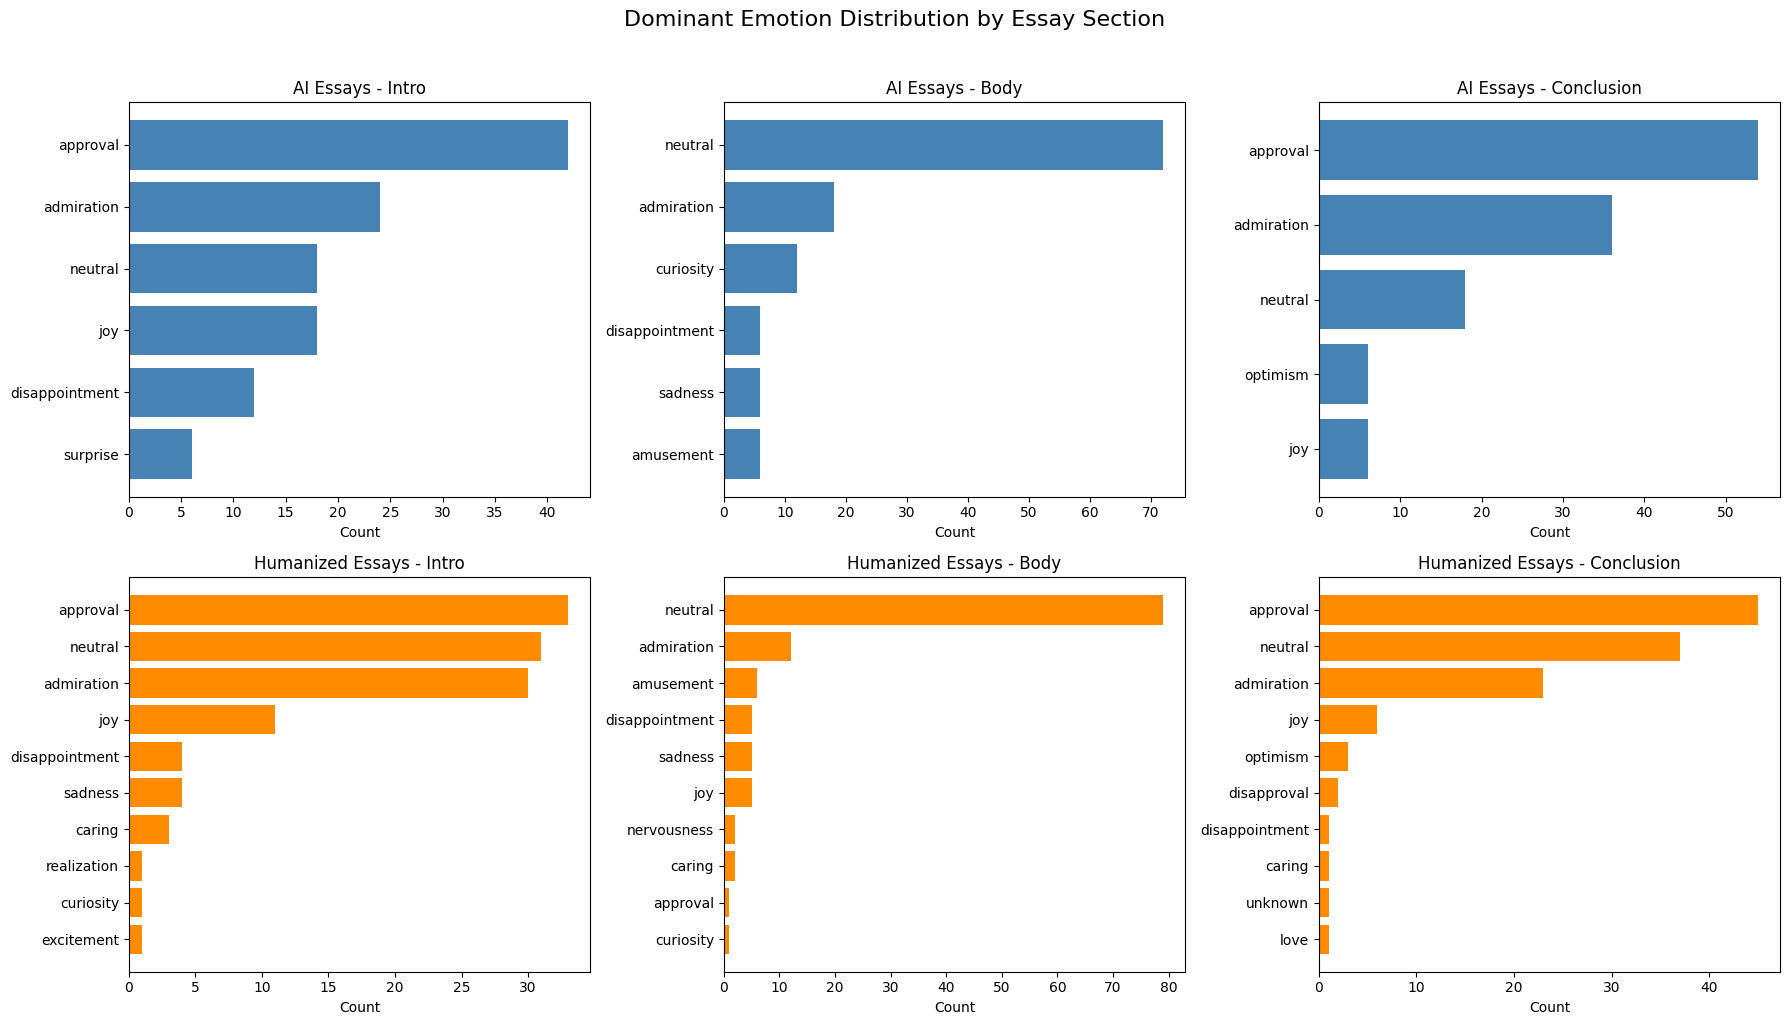

Insight: Compare how dominant emotions differ across Introduction, Body, and Conclusion


In [7]:
# Visualization 1: Top Emotion Distribution by Section (AI vs Humanized)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, section in enumerate(sections):
    # AI Essays
    ai_counts = df[f'AI_{section}_top'].value_counts().head(10)
    axes[0, i].barh(ai_counts.index, ai_counts.values, color='steelblue')
    axes[0, i].set_title(f'AI Essays - {section.capitalize()}', fontsize=12)
    axes[0, i].invert_yaxis()
    axes[0, i].set_xlabel('Count')
    
    # Humanized Essays
    human_counts = df[f'Human_{section}_top'].value_counts().head(10)
    axes[1, i].barh(human_counts.index, human_counts.values, color='darkorange')
    axes[1, i].set_title(f'Humanized Essays - {section.capitalize()}', fontsize=12)
    axes[1, i].invert_yaxis()
    axes[1, i].set_xlabel('Count')

plt.suptitle('Dominant Emotion Distribution by Essay Section', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Insight: Compare how dominant emotions differ across Introduction, Body, and Conclusion")

Showing 19 significant emotions (threshold: 0.02)


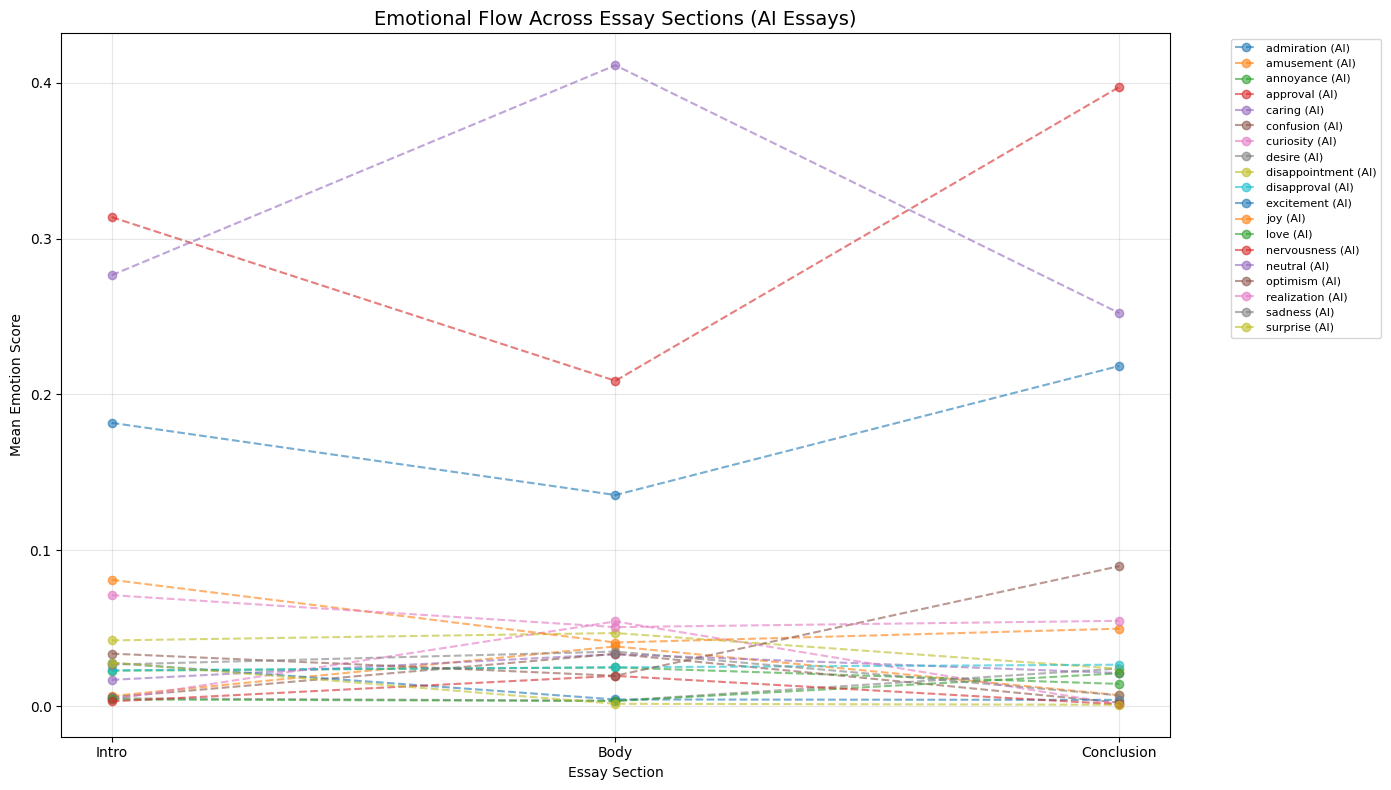

In [8]:
# Visualization 2: Emotional Flow Across Sections (Intro → Body → Conclusion)

# Get all unique emotions
sample_emotions = df['AI_intro_emotions'].iloc[0]
all_emotions = list(sample_emotions.keys()) if sample_emotions else []

# Calculate mean emotion scores per section
SIGNIFICANCE_THRESHOLD = 0.02  # Only show emotions with avg > 2%

flow_data = []
for essay_type in ['AI', 'Human']:
    for section in sections:
        col = f'{essay_type}_{section}_emotions'
        for emotion in all_emotions:
            mean_score = df[col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
            flow_data.append({
                'Essay Type': essay_type,
                'Section': section.capitalize(),
                'Emotion': emotion,
                'Mean Score': mean_score
            })

flow_df = pd.DataFrame(flow_data)

# Filter to significant emotions
emotion_max_scores = flow_df.groupby('Emotion')['Mean Score'].max()
significant_emotions = emotion_max_scores[emotion_max_scores >= SIGNIFICANCE_THRESHOLD].index.tolist()
flow_df_sig = flow_df[flow_df['Emotion'].isin(significant_emotions)]

print(f"Showing {len(significant_emotions)} significant emotions (threshold: {SIGNIFICANCE_THRESHOLD})")

# Create line plot for emotional flow
plt.figure(figsize=(14, 8))
section_order = ['Intro', 'Body', 'Conclusion']

for emotion in significant_emotions:
    subset = flow_df_sig[(flow_df_sig['Emotion'] == emotion) & (flow_df_sig['Essay Type'] == 'AI')]
    subset = subset.set_index('Section').loc[section_order]
    plt.plot(section_order, subset['Mean Score'], marker='o', linestyle='--', alpha=0.6, label=f'{emotion} (AI)')

plt.xlabel('Essay Section')
plt.ylabel('Mean Emotion Score')
plt.title('Emotional Flow Across Essay Sections (AI Essays)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

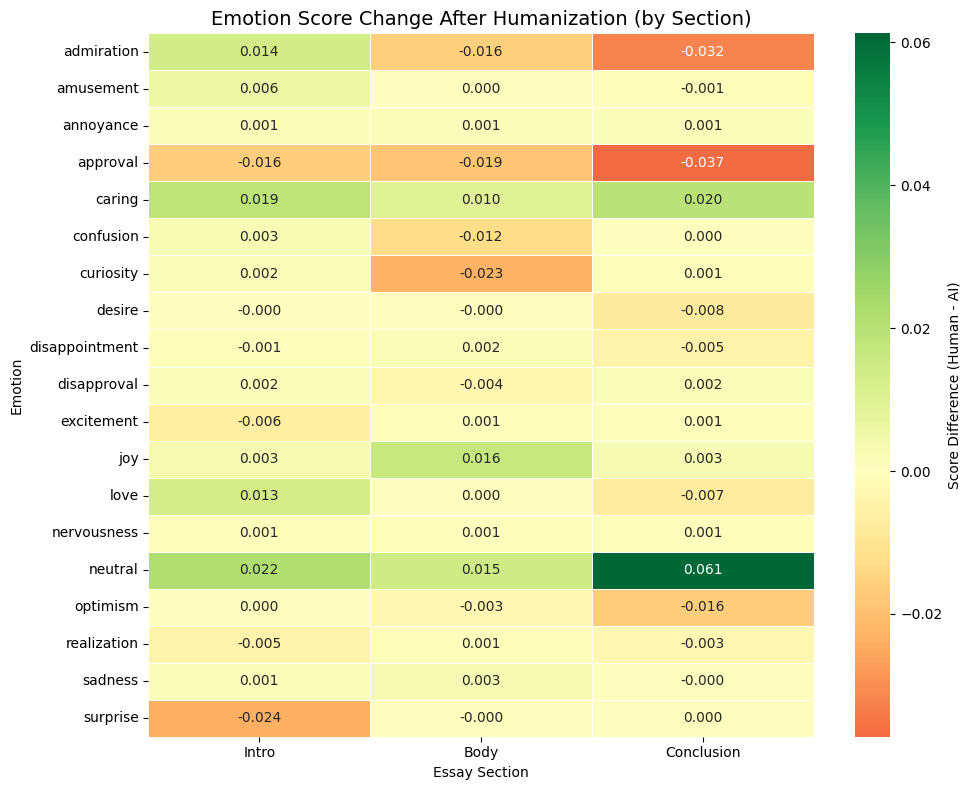

Interpretation:
- GREEN = Humanized essays have HIGHER scores for this emotion
- RED = Humanized essays have LOWER scores for this emotion


In [9]:
# Visualization 3: AI vs Humanized Comparison per Section (Heatmap)

# Calculate difference in emotion scores: Humanized - AI per section
diff_data = []
for section in sections:
    ai_col = f'AI_{section}_emotions'
    human_col = f'Human_{section}_emotions'
    
    for emotion in significant_emotions:
        ai_mean = df[ai_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
        human_mean = df[human_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
        diff_data.append({
            'Section': section.capitalize(),
            'Emotion': emotion,
            'Difference': human_mean - ai_mean
        })

diff_df = pd.DataFrame(diff_data)
diff_pivot = diff_df.pivot(index='Emotion', columns='Section', values='Difference')
diff_pivot = diff_pivot[['Intro', 'Body', 'Conclusion']]  # Order columns

plt.figure(figsize=(10, 8))
sns.heatmap(diff_pivot, cmap='RdYlGn', center=0, annot=True, fmt='.3f',
            linewidths=0.5, cbar_kws={'label': 'Score Difference (Human - AI)'})
plt.title('Emotion Score Change After Humanization (by Section)', fontsize=14)
plt.xlabel('Essay Section')
plt.ylabel('Emotion')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- GREEN = Humanized essays have HIGHER scores for this emotion")
print("- RED = Humanized essays have LOWER scores for this emotion")

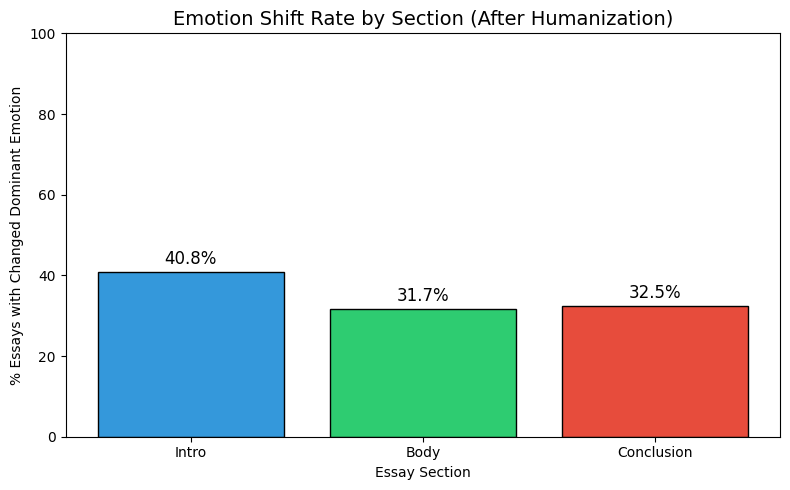

Insight: Shows which essay section experiences the most emotional change during humanization


In [10]:
# Visualization 4: Emotion Shift Rate by Section (Did humanization change the dominant emotion?)

shift_data = []
for section in sections:
    ai_col = f'AI_{section}_top'
    human_col = f'Human_{section}_top'
    
    # Calculate shift rate
    shifted = (df[ai_col] != df[human_col]).mean() * 100
    shift_data.append({
        'Section': section.capitalize(),
        'Shift Rate (%)': shifted
    })

shift_df = pd.DataFrame(shift_data)

plt.figure(figsize=(8, 5))
bars = plt.bar(shift_df['Section'], shift_df['Shift Rate (%)'], 
               color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
plt.ylabel('% Essays with Changed Dominant Emotion')
plt.xlabel('Essay Section')
plt.title('Emotion Shift Rate by Section (After Humanization)', fontsize=14)
plt.ylim(0, 100)

# Add value labels
for bar, val in zip(bars, shift_df['Shift Rate (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{val:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print("Insight: Shows which essay section experiences the most emotional change during humanization")

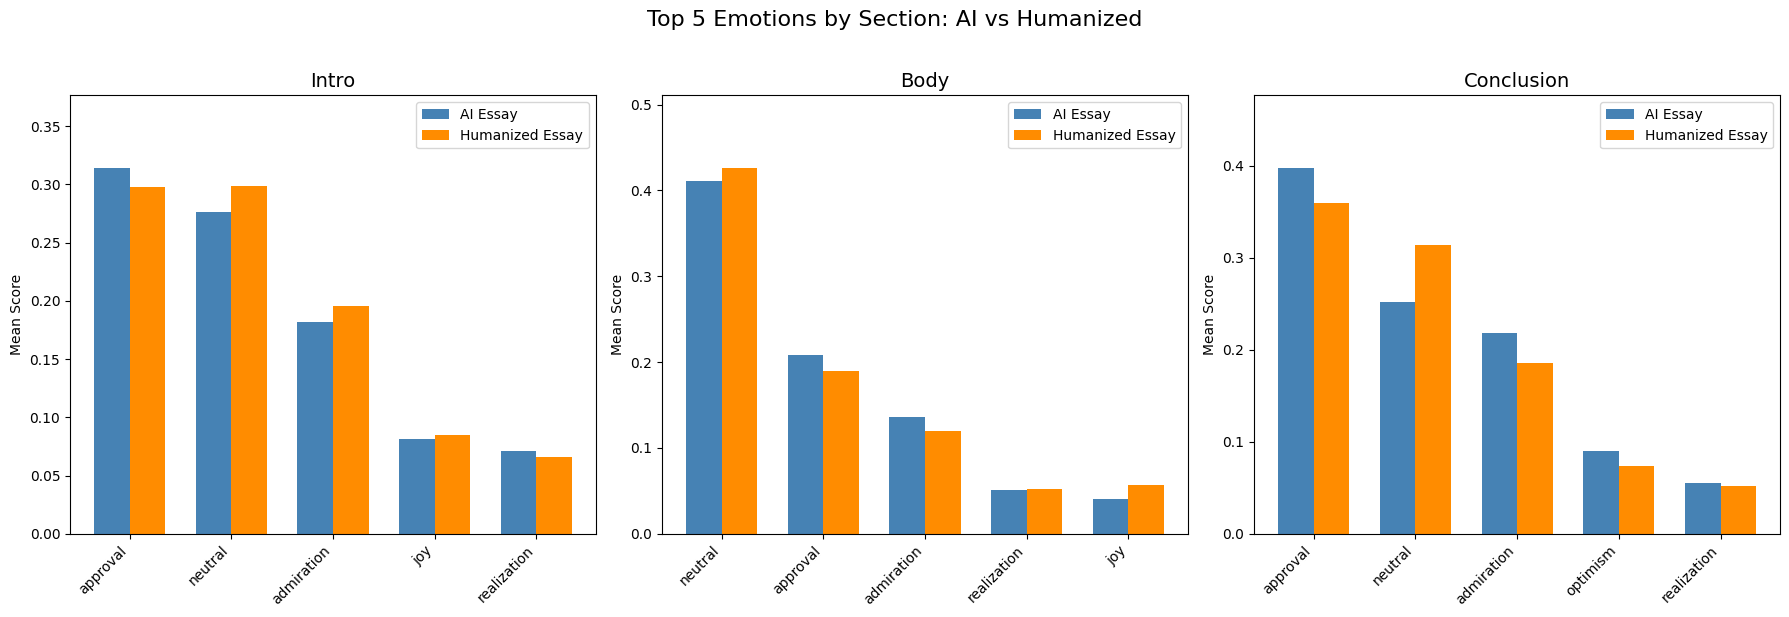

In [11]:
# Visualization 5: Grouped Bar Chart - Top 5 Emotions per Section (AI vs Humanized)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, section in enumerate(sections):
    # Get top 5 emotions for this section (based on combined AI+Human scores)
    ai_col = f'AI_{section}_emotions'
    human_col = f'Human_{section}_emotions'
    
    emotion_scores = {}
    for emotion in all_emotions:
        ai_mean = df[ai_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
        human_mean = df[human_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
        emotion_scores[emotion] = {'AI': ai_mean, 'Human': human_mean, 'Total': ai_mean + human_mean}
    
    # Sort by total and get top 5
    top_emotions = sorted(emotion_scores.keys(), key=lambda e: emotion_scores[e]['Total'], reverse=True)[:5]
    
    x = np.arange(len(top_emotions))
    width = 0.35
    
    ai_vals = [emotion_scores[e]['AI'] for e in top_emotions]
    human_vals = [emotion_scores[e]['Human'] for e in top_emotions]
    
    axes[idx].bar(x - width/2, ai_vals, width, label='AI Essay', color='steelblue')
    axes[idx].bar(x + width/2, human_vals, width, label='Humanized Essay', color='darkorange')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(top_emotions, rotation=45, ha='right')
    axes[idx].set_ylabel('Mean Score')
    axes[idx].set_title(f'{section.capitalize()}', fontsize=14)
    axes[idx].legend()
    axes[idx].set_ylim(0, max(max(ai_vals), max(human_vals)) * 1.2)

plt.suptitle('Top 5 Emotions by Section: AI vs Humanized', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

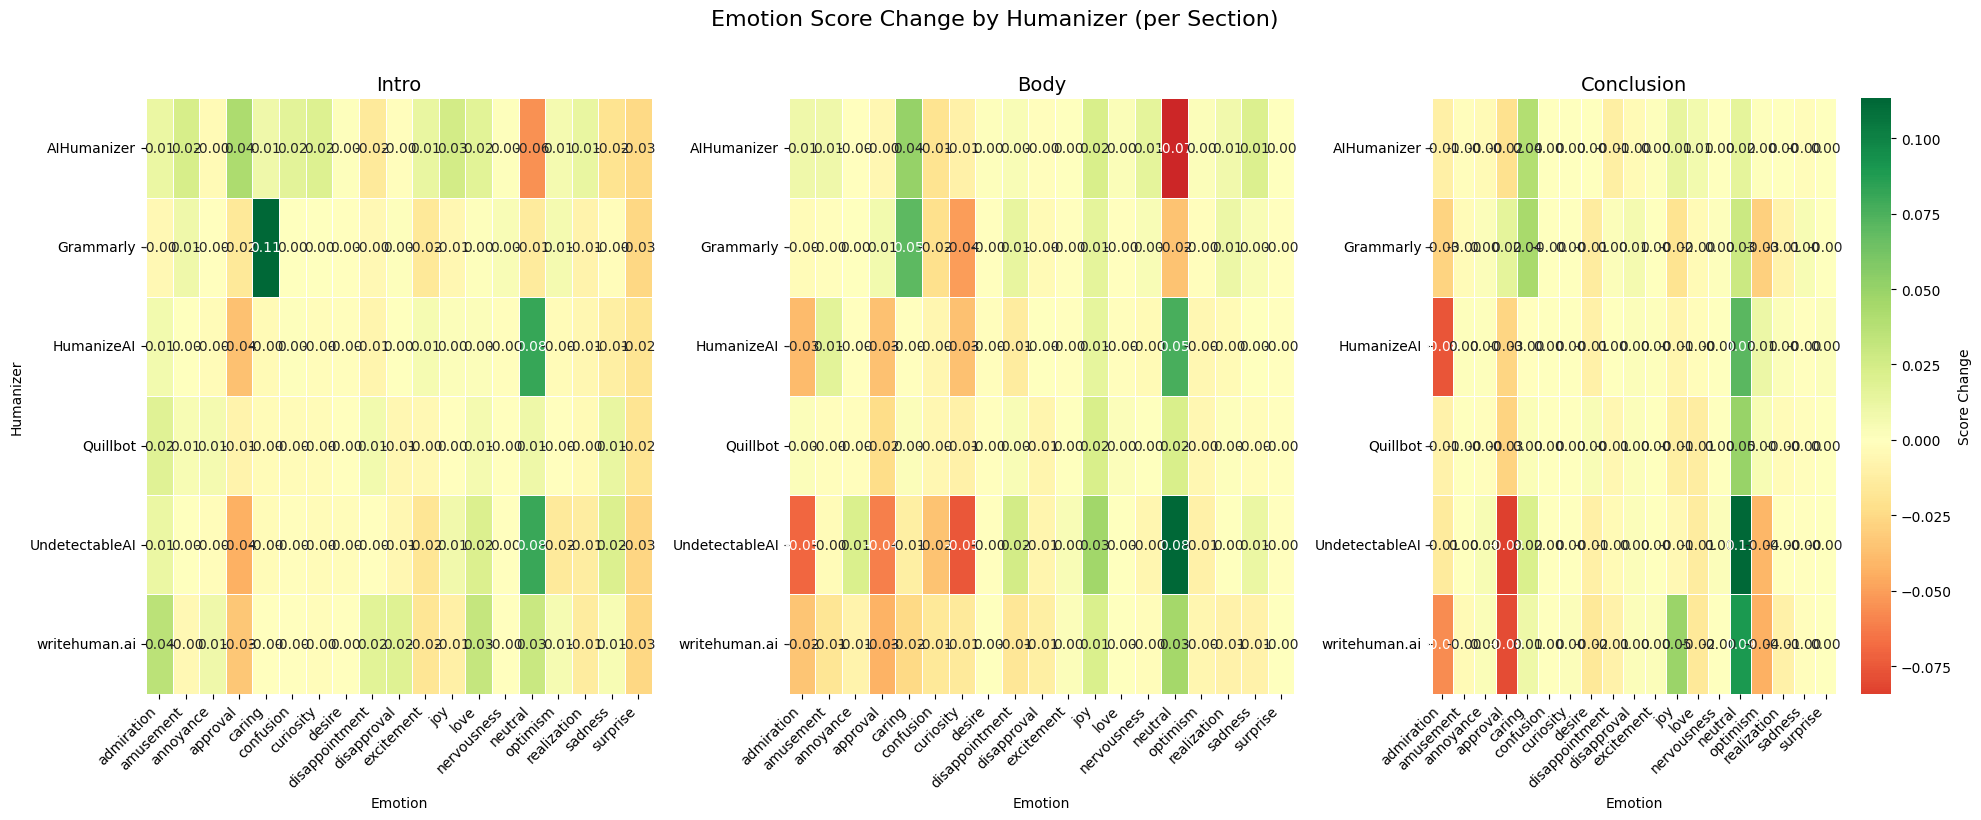

Interpretation: How each humanizer affects emotions in different essay sections


In [12]:
# Visualization 6: Emotion Change by Humanizer per Section (Faceted Heatmap)

humanizers = df['humanizer'].unique()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for idx, section in enumerate(sections):
    ai_col = f'AI_{section}_emotions'
    human_col = f'Human_{section}_emotions'
    
    # Calculate change per humanizer per emotion
    change_matrix = pd.DataFrame(index=humanizers, columns=significant_emotions)
    
    for humanizer in humanizers:
        subset = df[df['humanizer'] == humanizer]
        for emotion in significant_emotions:
            ai_mean = subset[ai_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
            human_mean = subset[human_col].apply(lambda x: x.get(emotion, 0) if x else 0).mean()
            change_matrix.loc[humanizer, emotion] = human_mean - ai_mean
    
    change_matrix = change_matrix.astype(float)
    
    sns.heatmap(change_matrix, ax=axes[idx], cmap='RdYlGn', center=0, 
                annot=True, fmt='.2f', linewidths=0.5, cbar=idx==2,
                cbar_kws={'label': 'Score Change'})
    axes[idx].set_title(f'{section.capitalize()}', fontsize=14)
    axes[idx].set_xlabel('Emotion')
    if idx == 0:
        axes[idx].set_ylabel('Humanizer')
    else:
        axes[idx].set_ylabel('')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Emotion Score Change by Humanizer (per Section)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation: How each humanizer affects emotions in different essay sections")

In [13]:
# Save results to CSV
output_cols = ['topic', 'length', 'AI_model', 'humanizer']
for section in sections:
    output_cols.extend([f'AI_{section}_top', f'Human_{section}_top'])

output_df = df[output_cols].copy()

# Add shift flags
for section in sections:
    output_df[f'{section}_shifted'] = df[f'AI_{section}_top'] != df[f'Human_{section}_top']

output_df.to_csv('emotion_chunked_results.csv', index=False)
print("Results saved to 'emotion_chunked_results.csv'")
display(output_df.head())

Results saved to 'emotion_chunked_results.csv'


,topic,length,AI_model,humanizer,AI_intro_top,Human_intro_top,AI_body_top,Human_body_top,AI_conclusion_top,Human_conclusion_top,intro_shifted,body_shifted,conclusion_shifted
0,1,2,gemini2.5pro,AIHumanizer,neutral,realization,disappointment,neutral,neutral,neutral,True,True,False
1,1,2,gemini2.5pro,Grammarly,neutral,neutral,disappointment,neutral,neutral,disapproval,False,True,True
2,1,2,gemini2.5pro,HumanizeAI,neutral,neutral,disappointment,neutral,neutral,neutral,False,True,False
3,1,2,gemini2.5pro,Quillbot,neutral,neutral,disappointment,neutral,neutral,neutral,False,True,False
4,1,2,gemini2.5pro,UndetectableAI,neutral,approval,disappointment,neutral,neutral,neutral,True,True,False
